In [ ]:
%pip install -q transformers datasets peft accelerate bitsandbytes trl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 19.4 MB/s eta 0:00:00


In [ ]:
import torch
import time
import gc
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)

from datasets import load_dataset
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

sns.set_theme(style="whitegrid", context="talk")

In [ ]:
def clear_gpu():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

In [4]:
def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, 100 * trainable / total

In [5]:
dataset = load_dataset("databricks/databricks-dolly-15k", split="train")
dataset = dataset.shuffle(seed=42).select(range(1500))

model_name = "Qwen/Qwen2-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

def format_example(example):
    return {
        "text": f"### Instruction:\n{example['instruction']}\n\n### Response:\n{example['response']}"
    }

dataset = dataset.map(format_example)

def tokenize(example):
    tokens = tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    tokens["labels"] = tokens["input_ids"].copy()

    tokens["labels"] = [
        token if mask == 1 else -100
        for token, mask in zip(tokens["labels"], tokens["attention_mask"])
    ]

    return tokens

tokenized_dataset = dataset.map(tokenize)
tokenized_dataset.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [ ]:
def run_experiment(run_name, lora_config=None, quantization_config=None):

    print(f"\n===== Starting {run_name} =====\n")

    clear_gpu()
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
    start_time = time.time()


    # MODEL LOADING


    if lora_config is None and quantization_config is None:
        # FPFT → FP32 + AMP
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            dtype=torch.float32
        )
        use_fp16 = True
    else:
        # LoRA / QLoRA
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            dtype=torch.float16,
            quantization_config=quantization_config
        )
        use_fp16 = False

    if quantization_config is not None:
        model = prepare_model_for_kbit_training(model)

    if lora_config is not None:
        model = get_peft_model(model, lora_config)

    total_params, trainable_params, percent = count_trainable_params(model)

    print(f"Trainable Params: {trainable_params:,}")
    print(f"Total Params: {total_params:,}")
    print(f"Trainable %: {percent:.4f}%")

    training_args = TrainingArguments(
        output_dir=f"./{run_name}",
        per_device_train_batch_size=2,
        gradient_accumulation_steps=8,
        num_train_epochs=1,
        logging_steps=20,
        save_strategy="no",
        learning_rate=2e-5,
        warmup_steps=5,
        fp16=use_fp16,
        bf16=False,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset
    )

    trainer.train()

    training_time = time.time() - start_time
    peak_memory = torch.cuda.max_memory_allocated() / (1024 ** 3) if torch.cuda.is_available() else 0.0

    logs = trainer.state.log_history
    losses = [log["loss"] for log in logs if "loss" in log]

    clear_gpu()

    return {
        "run_name": run_name,
        "losses": losses,
        "peak_memory": peak_memory,
        "training_time": training_time,
        "trainable_params": trainable_params,
        "percent": percent
    }

In [7]:
results_fpft = run_experiment("FPFT_16bit")


===== Starting FPFT_16bit =====



`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Trainable Params: 494,032,768
Total Params: 494,032,768
Trainable %: 100.0000%


Step,Training Loss
20,2.354465
40,2.271687
60,2.310107
80,2.226896


In [ ]:
from peft import LoraConfig
from transformers import BitsAndBytesConfig
import torch


# LoRA r=8

lora_r8 = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],  # Qwen attention projections
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)


# LoRA r=64

lora_r64 = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)


# QLoRA (4-bit NF4)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

In [9]:
results_lora8 = run_experiment(
    "LoRA_r8",
    lora_config=lora_r8
)


===== Starting LoRA_r8 =====



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Trainable Params: 540,672
Total Params: 494,573,440
Trainable %: 0.1093%


Step,Training Loss
20,2.700387
40,2.610930
60,2.648824
80,2.603323


In [10]:
results_lora64 = run_experiment(
    "LoRA_r64",
    lora_config=lora_r64
)


===== Starting LoRA_r64 =====



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Trainable Params: 4,325,376
Total Params: 498,358,144
Trainable %: 0.8679%


Step,Training Loss
20,2.620130
40,2.407749
60,2.427058
80,2.353307


In [11]:
results_qlora = run_experiment(
    "QLoRA_r8",
    lora_config=lora_r8,
    quantization_config=bnb_config
)


===== Starting QLoRA_r8 =====



Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Trainable Params: 540,672
Total Params: 315,660,160
Trainable %: 0.1713%


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
20,2.941725
40,2.828149
60,2.862969
80,2.839142


In [12]:
all_results = [
    results_fpft,
    results_lora8,
    results_lora64,
    results_qlora
]

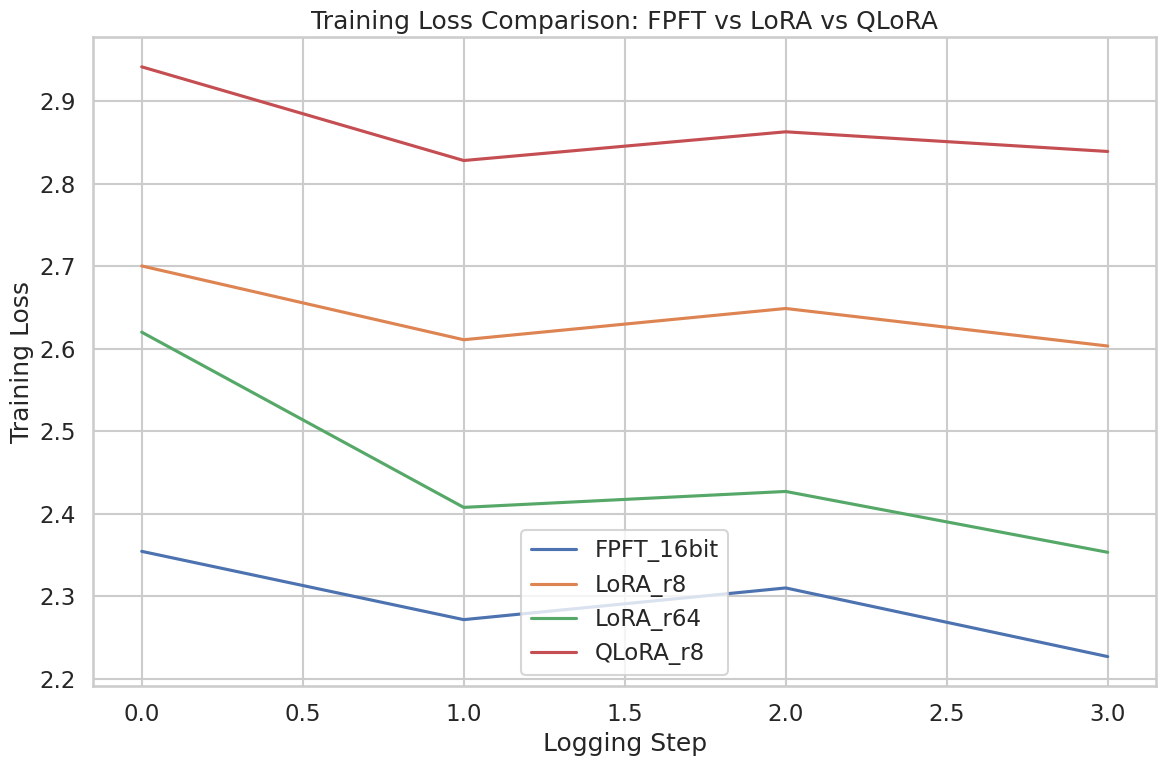

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

plt.figure(figsize=(12, 8))

for res in all_results:
    plt.plot(res["losses"], label=res["run_name"])

plt.xlabel("Logging Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison: FPFT vs LoRA vs QLoRA")
plt.legend()
plt.tight_layout()
plt.show()

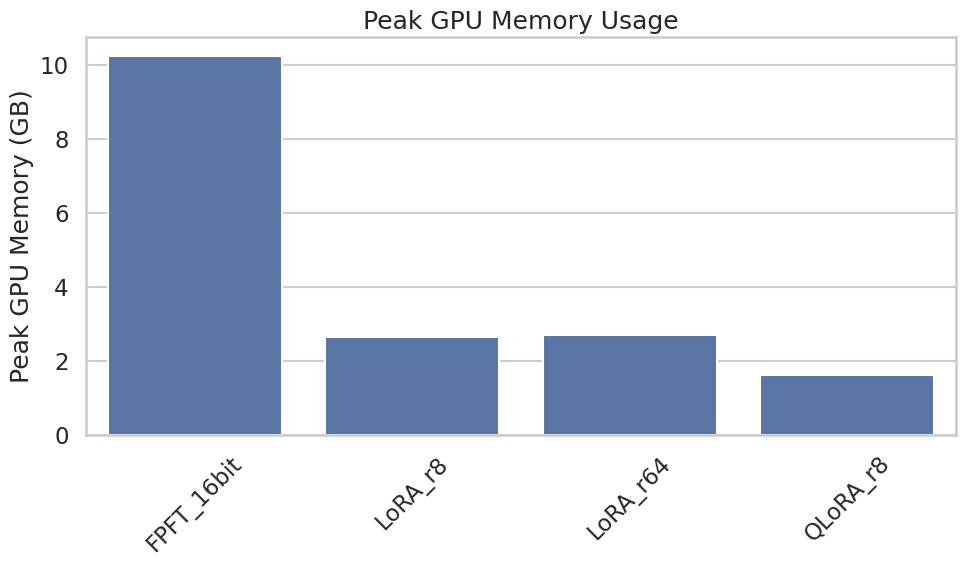

In [14]:
names = [r["run_name"] for r in all_results]
memory = [r["peak_memory"] for r in all_results]

plt.figure(figsize=(10, 6))
sns.barplot(x=names, y=memory)

plt.ylabel("Peak GPU Memory (GB)")
plt.title("Peak GPU Memory Usage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

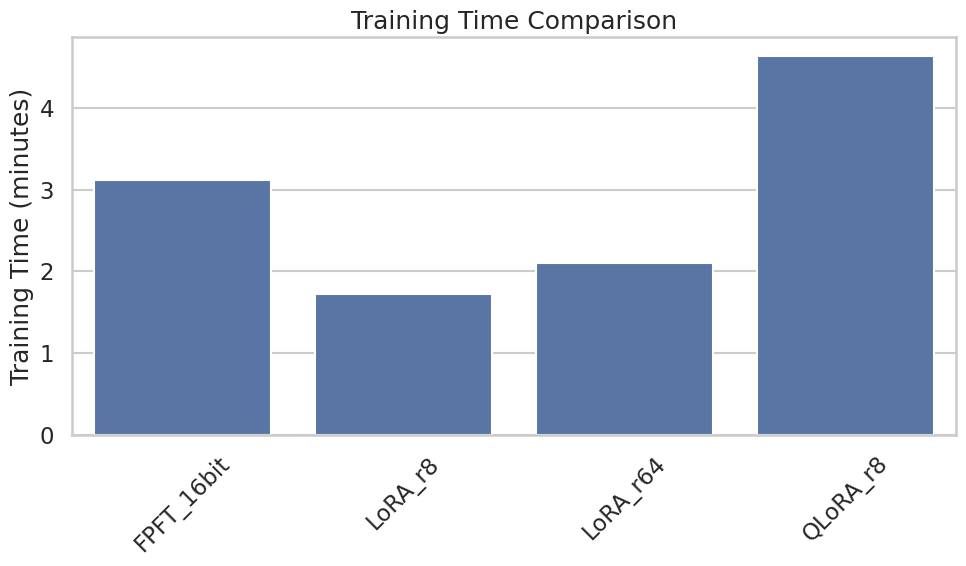

In [15]:
times = [r["training_time"] / 60 for r in all_results]

plt.figure(figsize=(10, 6))
sns.barplot(x=names, y=times)

plt.ylabel("Training Time (minutes)")
plt.title("Training Time Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()